# Day 10 Notebook

In [1]:
import torch
import numpy as np

In [2]:
data = [ [ 0, 1, 2 ], [3, 4, 5] ]

my_array = np.array(data, dtype=np.float32)

my_tensor = torch.tensor(my_array, requires_grad=True)

In [3]:
print(my_tensor)

tensor([[0., 1., 2.],
        [3., 4., 5.]], requires_grad=True)


In [4]:
print(my_tensor.grad)

None


In [5]:
print(my_tensor.shape)

torch.Size([2, 3])


In [6]:
mse_loss = torch.mean(torch.square(my_tensor))

In [7]:
print(mse_loss)

tensor(9.1667, grad_fn=<MeanBackward0>)


In [8]:
mse_loss.backward()

In [9]:
print(my_tensor.grad)

tensor([[0.0000, 0.3333, 0.6667],
        [1.0000, 1.3333, 1.6667]])


## Training Neural Networks with PyTorch

In [10]:
import torch.nn as nn

In [11]:

class FeedForwardNN(nn.Module):
    """ This is a module for a basic feed-forward neural network """

    def __init__(self, input_size, hidden_size, output_size):
        """ Constructs a feed-forward neural network """
        super().__init__() # <-- call constructor of nn.Module

        # create our model weights (input -> hidden, hidden -> output)
        self.hidden_layer = nn.Linear(input_size, hidden_size)
        self.output_layer = nn.Linear(hidden_size, output_size)

        # define our model activations:
        self.hidden_activation = nn.Tanh()
        self.output_activation = nn.Tanh()

    def forward(self, x):
        """ compute the prediction made by the neural network """

        # layer 1
        x2 = self.hidden_layer(x)
        x3 = self.hidden_activation(x2)
        # layer 2
        x4 = self.output_layer(x3)
        out = self.output_activation(x4)

        return out
        

In [12]:
from sklearn.preprocessing import StandardScaler
import numpy as np

def sinc_function(x1,x2):
    """ the function g(x) the network will be fit to """
    r = np.sqrt(x1**2 + x2**2)
    return np.sin(r) / r

# construct x_data:
grid_pts = np.linspace(-10, 10, 50)
X1, X2 = np.meshgrid(grid_pts, grid_pts)
data_x = np.array([
    X1.flatten(),
    X2.flatten()
]).T

# construct y_data:
data_y = sinc_function(data_x[:,0], data_x[:,1])
data_y = data_y.reshape(-1,1)

# standardize data:
scaler = StandardScaler()
data_z = scaler.fit_transform(data_x)

print('data_z shape:', data_z.shape)
print('data_y shape:', data_y.shape)

data_z shape: (2500, 2)
data_y shape: (2500, 1)


In [13]:
from torch.utils.data import Dataset

class NumpyDataset(Dataset):

    def __init__(self, data_z, data_y):

        super().__init__()
        
        self.data_z = torch.tensor(data_z, dtype=torch.float32)
        self.data_y = torch.tensor(data_y, dtype=torch.float32)


    def __len__(self):
        return len(data_z)

    def __getitem__(self, idx):
        z = self.data_z[idx]
        y = self.data_y[idx]
        
        return z, y

In [14]:
# neural network parameters:
input_size = 2
hidden_size = 80
output_size = 1

# training parameters
learning_rate = 1e-2
batch_size = 200
n_epochs = 400

In [15]:
from torch.utils.data import DataLoader

# create our model:
model = FeedForwardNN(input_size, hidden_size, output_size)

# create our dataset
dataset = NumpyDataset(data_z, data_y)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [16]:
import torch.optim as optim

loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


In [17]:
# list to record loss function over time
loss_history = []

for epoch in range(n_epochs):

    epoch_losses = []
    for z_batch, y_batch in data_loader:

        # clean up any remaining gradients:
        optimizer.zero_grad()

        # compute batch predictions:
        y_hat_batch = model(z_batch)

        # compute loss
        loss = loss_function(y_hat_batch, y_batch)
        epoch_losses.append(loss.item())

        # backpropagate the loss:
        loss.backward()
        optimizer.step()

    loss_history.append(np.mean(epoch_losses))

  

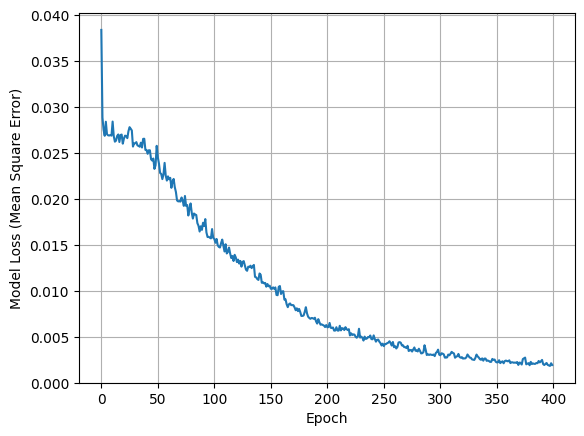

In [18]:
import matplotlib.pyplot as plt

plt.figure()
plt.grid()
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Model Loss (Mean Square Error)')
plt.show()

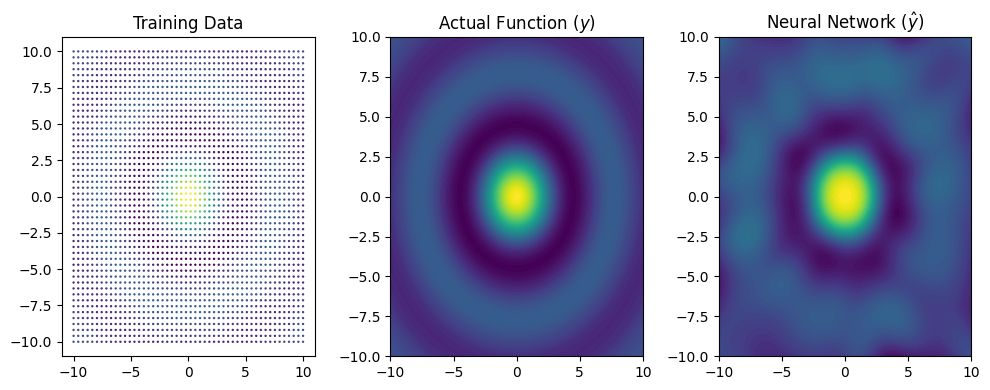

In [19]:
import matplotlib.pyplot as plt

eval_pts = np.linspace(-10, 10, 100)
eval_X1, eval_X2 = np.meshgrid(eval_pts, eval_pts)

eval_x = np.array([ eval_X1.flatten(), eval_X2.flatten() ]).T
eval_z = scaler.transform(eval_x)
eval_z_tensor = torch.tensor(eval_z, dtype=torch.float32)
eval_z = np.array(model(eval_z_tensor).detach().numpy())
model_yhat = eval_z.reshape(eval_X1.shape)

plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.scatter(data_x[:,0], data_x[:,1], c=data_y, s=0.5)
plt.title('Training Data')

plt.subplot(1,3,2)
plt.contourf(eval_X1, eval_X2, sinc_function(eval_X1,eval_X2), levels=100)
plt.title(r'Actual Function ($y$)')

plt.subplot(1,3,3)
plt.title('Neural Network ($\hat{y}$)')
plt.contourf(eval_X1, eval_X2, model_yhat, levels=100)

plt.tight_layout()
plt.show()

## Application: Predicting Crystal Structure from XRD Data

In [20]:
# import requests

# CSV_URL = 'https://raw.githubusercontent.com/cburdine/materials-ml-workshop/main/MaterialsML/neural_networks/xrd_dataset_full.csv.gz'

# r = requests.get(CSV_URL)
# with open('xrd_dataset_full.csv.gz', 'wb') as f:
#     f.write(r.content)

In [21]:
import pandas as pd

In [22]:
data_df = pd.read_csv('xrd_dataset_full.csv.gz', compression='gzip')

In [23]:
display(data_df)

,mp_id,formula,composition,crystal_system,symmetry_symbol,cell_params,energy_above_hull,xray_peaks,xray_intensities
0,mp-676840,Ag13(PbO3)6,"{'Ag': 26, 'Pb': 12, 'O': 36}",triclinic,P1,"(6.002268, 10.397799745616618, 19.466327337319...",0.007080,"[4.539,8.504,9.086,9.625,9.662,12.428,12.486,1...","[2.848,0.094,6.001,3.006,2.908,4.037,4.086,46...."
1,mp-685283,Ag13Bi15I64,"{'Ag': 13, 'Bi': 15, 'I': 64}",triclinic,P1,"(8.894472385608267, 9.034189542918936, 59.5692...",0.083551,"[1.485,2.970,4.455,5.941,7.429,8.917,10.407,11...","[100.000,0.282,0.843,0.044,0.360,0.059,2.260,0..."
2,mp-1229151,Ag15S5I4Br,"{'Ag': 15, 'S': 5, 'I': 4, 'Br': 1}",triclinic,P1,"(6.993913570662637, 8.558995140558554, 10.9872...",0.065281,"[8.805,10.757,11.873,13.371,13.441,15.703,16.3...","[0.410,0.293,0.217,0.223,0.179,0.159,0.162,0.1..."
3,mp-759792,Ag2B8O13,"{'Ag': 8, 'B': 32, 'O': 52}",triclinic,P1,"(7.898226, 10.663953129513134, 12.038956354262...",0.011548,"[7.451,8.414,10.253,11.203,12.162,13.467,13.46...","[2.472,0.055,0.002,0.459,0.076,33.647,27.434,8..."
4,mp-686742,Ag2H21N7(ClO4)2,"{'Ag': 2, 'H': 21, 'N': 7, 'Cl': 2, 'O': 8}",triclinic,P1,"(8.185132, 8.714175033958062, 9.08744340539081...",0.700030,"[10.854,10.961,11.426,11.674,14.809,15.183,15....","[8.524,100.000,65.581,91.596,2.314,4.840,1.231..."
...,...,...,...,...,...,...,...,...,...
91140,mp-1364038,Zn3Si3(SnO6)2,"{'Zn': 24, 'Si': 24, 'Sn': 16, 'O': 96}",cubic,Ia-3d,"(12.35908, 12.35908, 12.35908, 90.0, 90.0, 90.0)",0.308748,"[17.577,20.324,26.994,28.897,32.396,34.024,35....","[5.740,45.839,4.501,67.368,55.614,0.429,100.00..."
91141,mp-1163950,Zn3Si3(WO6)2,"{'Zn': 24, 'Si': 24, 'W': 16, 'O': 96}",cubic,Ia-3d,"(12.137336, 12.137336, 12.137336, 90.0, 90.0, ...",0.226553,"[17.901,20.699,27.497,29.436,33.005,34.665,36....","[3.294,74.831,2.346,56.137,25.406,0.374,100.00..."
91142,mp-1327509,Zn3Sn2(GeO4)3,"{'Zn': 24, 'Sn': 16, 'Ge': 24, 'O': 96}",cubic,Ia-3d,"(12.573034, 12.573034, 12.573034, 90.0, 90.0, ...",0.227320,"[17.276,19.974,26.526,28.395,31.830,33.428,34....","[0.201,16.587,0.840,64.249,87.208,4.704,100.00..."
91143,mp-648774,Zr2Cl5,"{'Zr': 96, 'Cl': 240}",cubic,Ia-3d,"(21.790819064017104, 21.790819064017104, 21.79...",0.059570,"[9.943,11.486,15.213,16.271,18.207,19.104,19.9...","[0.626,100.000,6.746,1.780,0.009,2.667,4.761,0..."


In [24]:
import ast

ELEMENTS = set()
for v in data_df['composition'].values:
    ELEMENTS |= set(ast.literal_eval(v).keys())
ELEMENTS = sorted(list(ELEMENTS))

CRYSTAL_SYSTEMS = sorted(set(data_df['crystal_system'].values))

SYMM_SYMBOLS = sorted(set(data_df['symmetry_symbol'].values))

In [25]:
print(len(ELEMENTS))
print(ELEMENTS)

88
['Ac', 'Ag', 'Al', 'Ar', 'As', 'Au', 'B', 'Ba', 'Be', 'Bi', 'Br', 'C', 'Ca', 'Cd', 'Ce', 'Cl', 'Co', 'Cr', 'Cs', 'Cu', 'Dy', 'Er', 'Eu', 'F', 'Fe', 'Ga', 'Gd', 'Ge', 'H', 'He', 'Hf', 'Hg', 'Ho', 'I', 'In', 'Ir', 'K', 'Kr', 'La', 'Li', 'Lu', 'Mg', 'Mn', 'Mo', 'N', 'Na', 'Nb', 'Nd', 'Ni', 'Np', 'O', 'Os', 'P', 'Pa', 'Pb', 'Pd', 'Pm', 'Pr', 'Pt', 'Pu', 'Rb', 'Re', 'Rh', 'Ru', 'S', 'Sb', 'Sc', 'Se', 'Si', 'Sm', 'Sn', 'Sr', 'Ta', 'Tb', 'Tc', 'Te', 'Th', 'Ti', 'Tl', 'Tm', 'U', 'V', 'W', 'Xe', 'Y', 'Yb', 'Zn', 'Zr']


In [26]:
print(CRYSTAL_SYSTEMS)

['cubic', 'hexagonal', 'monoclinic', 'orthorhombic', 'tetragonal', 'triclinic', 'trigonal']


In [27]:
print(SYMM_SYMBOLS)
print(len(SYMM_SYMBOLS))

['Aea2', 'Aem2', 'Ama2', 'Amm2', 'C2', 'C2/c', 'C2/m', 'C222', 'C222_1', 'Cc', 'Ccc2', 'Ccce', 'Cccm', 'Cm', 'Cmc2_1', 'Cmce', 'Cmcm', 'Cmm2', 'Cmme', 'Cmmm', 'F-43c', 'F-43m', 'F222', 'F23', 'F432', 'F4_132', 'Fd-3', 'Fd-3c', 'Fd-3m', 'Fdd2', 'Fddd', 'Fm-3', 'Fm-3c', 'Fm-3m', 'Fmm2', 'Fmmm', 'I-4', 'I-42d', 'I-42m', 'I-43d', 'I-43m', 'I-4c2', 'I-4m2', 'I222', 'I23', 'I2_12_12_1', 'I2_13', 'I4', 'I4/m', 'I4/mcm', 'I4/mmm', 'I422', 'I432', 'I4_1', 'I4_1/a', 'I4_1/acd', 'I4_1/amd', 'I4_122', 'I4_132', 'I4_1cd', 'I4_1md', 'I4cm', 'I4mm', 'Ia-3', 'Ia-3d', 'Iba2', 'Ibam', 'Ibca', 'Im-3', 'Im-3m', 'Ima2', 'Imm2', 'Imma', 'Immm', 'P-1', 'P-3', 'P-31c', 'P-31m', 'P-3c1', 'P-3m1', 'P-4', 'P-42_1c', 'P-42_1m', 'P-42c', 'P-42m', 'P-43m', 'P-43n', 'P-4b2', 'P-4c2', 'P-4m2', 'P-4n2', 'P-6', 'P-62c', 'P-62m', 'P-6c2', 'P-6m2', 'P1', 'P2', 'P2/c', 'P2/m', 'P222', 'P222_1', 'P23', 'P2_1', 'P2_1/c', 'P2_1/m', 'P2_12_12', 'P2_12_12_1', 'P2_13', 'P3', 'P312', 'P31c', 'P31m', 'P321', 'P3_1', 'P3_112', 'P3

In [28]:
# generate the mapping from 
# symmetry_symbol -> crystal_system:
SYMM_SYMBOL_MAP = {}
for _, row in data_df.iterrows():
    system = row['crystal_system']
    symm = row['symmetry_symbol']
    SYMM_SYMBOL_MAP[symm] = system

In [31]:
import ast

def parse_xrd_data(row):

    peaks = ast.literal_eval(row['xray_peaks'])
    ints = ast.literal_eval(row['xray_intensities'])

    return peaks, ints

In [33]:
import matplotlib.pyplot as plt

def plot_xrd(peaks, intensities):

    plt.figure()
    for x, y in zip(peaks, intensities):
        plt.plot([x,x], [0,y], color='b', linewidth=2)

    plt.axhline(color='b')
    plt.xlim((0,90))
    plt.grid()
    plt.xlabel(r'Diffraction Angle $2\theta$ [degrees]')
    plt.ylabel('Intensity [arb. units]')
    plt.show()

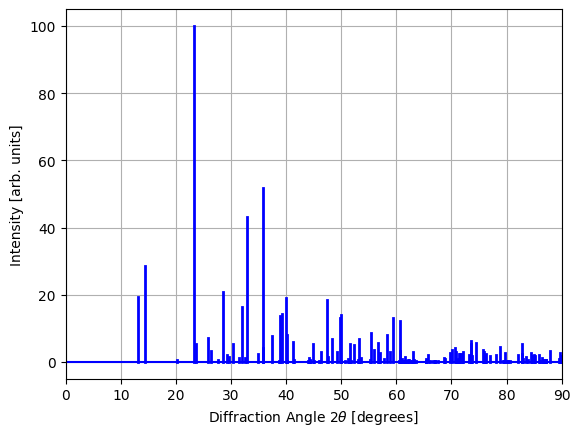

Nd2NCl3


In [36]:
example_idx = 23000
plot_xrd(*parse_xrd_data(data_df.iloc[example_idx]))
print(data_df.at[example_idx, 'formula'])

In [37]:
def vectorize_xrd_spectrum(peaks, intensities, intensity_scale=100, bins=90):
    hist, _ = np.histogram(
        peaks, bins=bins,
        range=(0,90),
        weights=intensities)

    return hist / intensity_scale


print(vectorize_xrd_spectrum(*parse_xrd_data(data_df.iloc[example_idx])))

[0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
 0.00000e+00 1.91780e-01 2.86540e-01 0.00000e+00 0.00000e+00 0.00000e+00
 0.00000e+00 0.00000e+00 5.72000e-03 0.00000e+00 0.00000e+00 1.05213e+00
 0.00000e+00 7.20800e-02 3.16800e-02 6.81000e-03 2.08490e-01 3.57800e-02
 5.31300e-02 1.12000e-02 6.06500e-01 0.00000e+00 2.29500e-02 5.59120e-01
 0.00000e+00 7.58900e-02 1.39670e-01 3.32630e-01 8.21000e-02 6.69600e-02
 0.00000e+00 1.88000e-03 7.51100e-02 7.09000e-03 3.03500e-02 1.99560e-01
 6.67500e-02 3.03110e-01 2.22000e-03 7.11700e-02 4.97900e-02 9.12300e-02
 6.50000e-04 1.24630e-01 6.10100e-02 3.52400e-02 1.12260e-01 1.32270e-01
 1.55680e-01 3.19100e-02 1.91300e-02 3.79000e-02 2.25000e-03 3.82400e-02
 8.60000e-03 6.38000e-03 2.24700e-02 2.63200e-02 1.09860e-01 8.63800e-02
 3.06700e-02 1.56490e-01 5.85100e-02 8.93300e-02 2.67700e-02 1.99500e-02
 6.73600e-02 3.24900e-02 8.78000e-03 5.40000e-04 1.

In [38]:
def vectorize_symmetry(symmetry_symbol, symbols):
    vec = np.zeros(len(symbols))
    if symmetry_symbol in symbols:
        vec[symbols.index(symmetry_symbol)] = 1.0

    return vec

In [39]:
def parse_data_vector(row):
    """ parses x and y vectors from a dataframe row """
    
    # parse the xray peaks and intensities
    peaks, ints = parse_xrd_data(row)
    
    # parse feature vector (x):
    x_vector = vectorize_xrd_spectrum(peaks, ints)
    
    # parse label vector (y):
    y_vector = vectorize_symmetry(
        row['symmetry_symbol'], symbols=SYMM_SYMBOLS)
    
    return x_vector, y_vector

In [40]:
from torch.utils.data import Dataset
from tqdm import tqdm

# Define a custom dataset class
class XRDDataset(Dataset):
    def __init__(self, xrd_df):

        data_x = []
        data_y = []

        # parse data from datafrane
        for _, row in tqdm(xrd_df.iterrows(), total=len(xrd_df)):
            x, y = parse_data_vector(row)
            data_x.append(x)
            data_y.append(y)

        np_data_x = np.array(data_x)
        np_data_y = np.array(data_y)

        # convert data to pytorch tensors
        self.data_x = torch.tensor(np_data_x, dtype=torch.float32)
        self.data_y = torch.tensor(np_data_y, dtype=torch.float32)
        
    def __len__(self):
        """ returns the size of this dataset"""
        return len(self.data_x)
    
    def __getitem__(self, idx):
        """ Gets the (x,y) pair at index 'idx' """
        x = self.data_x[idx]
        y = self.data_y[idx]
        return x, y

In [41]:
dataset = XRDDataset(data_df)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 91145/91145 [02:25<00:00, 625.66it/s]


In [43]:
from torch.utils.data import random_split

train_dataset, val_dataset, test_dataset = random_split(dataset, [0.8, 0.1, 0.1])

In [49]:
import torch
import torch.nn as nn

# Define the neural network class (XRDNet)
class XRDNet(nn.Module):

    def __init__(self, input_size, hidden_layer_sizes, output_size):
        """ Constructs a feed-forward neural network with many hidden layers"""
        super().__init__()

        layer_sizes = [input_size]
        layer_sizes.extend(hidden_layer_sizes)
        layer_sizes.append(output_size)
        
        self.hidden_layers = nn.ParameterList([
            nn.Linear(size_in, size_out)
            for size_in, size_out in 
            zip(layer_sizes[:-1], layer_sizes[1:])
        ])

        # define hidden layer activation function:
        self.activation = nn.SiLU()

        # use the softmax activation (only when classifying)
        self.out_activation = nn.Softmax(dim=-1)

    def forward(self, x):
        """ Estimates the log-likelihood of each output feature"""
        for layer in self.hidden_layers[:-1]:
            x = self.activation(layer(x))
        
        out = self.hidden_layers[-1](x)

        return out
    
    def classify(self, x):
        """ Estimates the normalized output probability of each output feature"""
        
        out = self.forward(x)
        return self.out_activation(out)

In [50]:
model = XRDNet(
    input_size=len(dataset[0][0]),
    hidden_layer_sizes= [512, 256, 128],
    output_size=len(dataset[0][1]),
)

In [51]:
def eval_model_loss(model, data_loader, loss_fn):
    
    loss = []
    with torch.no_grad():
        for z_batch, y_batch in data_loader:
            loss.append(loss_fn(model(z_batch), y_batch))

    mean_loss = torch.stack(loss).mean().item()

    return mean_loss

def eval_model_accuracy(model, data_loader):
    acc = []
    with torch.no_grad():
        for z_batch, y_batch in data_loader:
            pred_class = model.classify(z_batch).argmax(dim=-1)
            true_class = y_batch.argmax(dim=-1)
            acc.append((pred_class == true_class).to(torch.float32).mean())

    mean_acc = torch.stack(acc).mean().item()

    return mean_acc

In [52]:
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

def fit_model(model, train_dataset, val_dataset, n_epochs=100, batch_size=64, lr=1e-3, wd=1e-3):

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.CrossEntropyLoss()
    
    # create a dict to record losses during training
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    # main training loop (fixed number of epochs)
    for epoch in range(n_epochs):
        
        # apply stochastic gradient descent step to each batch in dataset
        print(f'Epoch {epoch}')
        epoch_losses = []
        for z_batch, y_batch in tqdm(train_loader):
            
            # zero optimizer gradients
            optimizer.zero_grad()
    
            # generate batch prediction
            y_hat_batch = model(z_batch)
            
            # compute loss
            loss = loss_fn(y_hat_batch, y_batch)
            epoch_losses.append(loss.item())
    
            # backpropagate loss
            loss.backward()
            optimizer.step()

        # evaluate epoch training and validation losses:
        train_loss = eval_model_loss(model, train_loader, loss_fn)
        val_loss = eval_model_loss(model, val_loader, loss_fn)

        # evaluate epoch accuracies:
        train_acc = eval_model_accuracy(model, train_loader)
        val_acc = eval_model_accuracy(model, val_loader)
        
        print(f'Train loss: {train_loss}; Val loss: {val_loss}')
        print(f'Train acc: {train_acc}; Val acc: {val_acc}')

        # record losses in history dictionary
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
    
    return history

In [53]:
history = fit_model(
    model, 
    train_dataset, 
    val_dataset, 
    batch_size=512,
    n_epochs=40,
    lr=1e-3,
    wd=1e-1
)

Epoch 0


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 143/143 [00:03<00:00, 47.57it/s]


Train loss: 3.883754014968872; Val loss: 3.8921597003936768
Train acc: 0.12630721926689148; Val acc: 0.12216982245445251
Epoch 1


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 143/143 [00:03<00:00, 43.73it/s]


Train loss: 3.64652156829834; Val loss: 3.6569011211395264
Train acc: 0.17603754997253418; Val acc: 0.17837536334991455
Epoch 2


...

Train loss: 1.8139894008636475; Val loss: 2.4051129817962646
Train acc: 0.5417099595069885; Val acc: 0.45896053314208984
Epoch 38


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 143/143 [00:03<00:00, 45.18it/s]


Train loss: 1.8025975227355957; Val loss: 2.40641188621521
Train acc: 0.5438545346260071; Val acc: 0.46308380365371704
Epoch 39


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 143/143 [00:02<00:00, 48.89it/s]


Train loss: 1.7854962348937988; Val loss: 2.4124791622161865
Train acc: 0.5457583069801331; Val acc: 0.4620257616043091
